# Módulo 3: Modelos Avanzados
### Ensembles, Deep Learning y Aprendizaje por Refuerzo
**Workshop: IA aplicada a Distribución de Energía**
**Presentado por: Dr. Francisco Arduh - Xcapit**

---

## Repaso de Módulos 1-2

| Módulo | Lo que aprendimos |
|--------|------------------|
| 1 | Regresión (predecir demanda), Feature Engineering, Árbol de Decisión |
| 2 | Clasificación (detectar anomalías), K-Means, PCA, CRISP-DM |

## ¿Qué viene hoy?

En los módulos anteriores usamos modelos "individuales" (un solo árbol, una sola regresión). Hoy vamos a ver qué pasa cuando **combinamos muchos modelos** (ensembles), cuando usamos **redes neuronales** (Deep Learning), y cómo un modelo puede **aprender a tomar decisiones** por sí solo (Aprendizaje por Refuerzo).

## Agenda de Hoy (~2 horas)

| Bloque | Tema | Duración |
|--------|------|----------|
| 1 | Modelos de Ensamble: Random Forest y XGBoost | ~40 min |
| 2 | Deep Learning para series temporales | ~50 min |
| 3 | Aprendizaje por Refuerzo (conceptual + demo) | ~30 min |

In [1]:
# Instalar XGBoost (no viene en Colab por defecto)
!pip install -q xgboost

In [2]:
# Importar librerias
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import mean_absolute_error
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import MinMaxScaler
import xgboost as xgb

sns.set(style="whitegrid")
print("Librerias cargadas.")

Librerias cargadas.


In [3]:
# Regenerar datos (misma semilla que modulos anteriores)
np.random.seed(42)
fechas = pd.date_range("2024-01-01", "2024-12-31 23:00:00", freq="h")
n = len(fechas)
dia_del_ano = fechas.dayofyear
hora = fechas.hour
temperatura = 20 - 12*np.cos(2*np.pi*dia_del_ano/365) + 4*np.sin(2*np.pi*hora/24) + np.random.normal(0, 2, n)
demanda = 300 + 0.8*(temperatura - 20)**2 + 8*np.sin(2*np.pi*(hora - 6)/24) + np.random.normal(0, 5, n)

df = pd.DataFrame({
    'fecha': fechas, 'temperatura': np.round(temperatura, 1),
    'hora': hora, 'dia_semana': fechas.dayofweek,
    'es_finde': (fechas.dayofweek >= 5).astype(int),
    'demanda_MW': np.round(demanda, 1)
})

# Split y features (como en modulos anteriores)
corte = int(len(df) * 0.8)
features = ['temperatura', 'hora', 'dia_semana', 'es_finde']
X_train = df.iloc[:corte][features]
X_test = df.iloc[corte:][features]
y_train = df.iloc[:corte]['demanda_MW']
y_test = df.iloc[corte:]['demanda_MW']

print(f"Train: {len(X_train)}, Test: {len(X_test)}")

Train: 7027, Test: 1757


### Modelos base del Módulo 1 (para comparar)

Antes de probar los modelos nuevos, necesitamos un **punto de referencia**. Vamos a re-entrenar los modelos del Módulo 1 para poder comparar.

In [4]:
# Baseline: promedio
mae_baseline = mean_absolute_error(y_test, [y_train.mean()] * len(y_test))

# Regresion Lineal
lr = LinearRegression().fit(X_train, y_train)
mae_lr = mean_absolute_error(y_test, lr.predict(X_test))

# Arbol de Decision
dt = DecisionTreeRegressor(max_depth=5, random_state=42).fit(X_train, y_train)
mae_dt = mean_absolute_error(y_test, dt.predict(X_test))

print(f"Baseline (promedio):   MAE = {mae_baseline:.2f} MW")
print(f"Regresion Lineal:      MAE = {mae_lr:.2f} MW")
print(f"Arbol de Decision:     MAE = {mae_dt:.2f} MW")

Baseline (promedio):   MAE = 50.70 MW
Regresion Lineal:      MAE = 59.24 MW
Arbol de Decision:     MAE = 10.02 MW


> **Lectura de resultados:** El MAE (Mean Absolute Error) nos dice cuántos MW se equivoca el modelo en promedio. **Cuanto menor, mejor.** El baseline (simplemente predecir el promedio) es nuestra referencia mínima — cualquier modelo útil debería superar esto. Fíjense que ya el Árbol de Decisión mejora bastante respecto al baseline y la regresión lineal.

---
## Bloque 1: Modelos de Ensamble

![Ensamble](https://static.vecteezy.com/system/resources/previews/000/363/411/non_2x/vector-people-in-the-crowd-raising-hand-to-show-support-and-vote.jpg)

### 1.1 La idea central

Un solo árbol de decisión puede equivocarse. Pero si consultamos a **muchos árboles** y promediamos sus respuestas, el resultado es más robusto.

Dos estrategias principales:

| Estrategia | Cómo funciona | Ejemplo |
|-----------|---------------|--------|
| **Bagging** | Muchos árboles en paralelo, cada uno con un subconjunto aleatorio de datos | Random Forest |
| **Boosting** | Árboles en serie, cada uno corrige los errores del anterior | XGBoost |

### 1.2 Random Forest (Bosque Aleatorio)

![RandomForest](https://miro.medium.com/v2/1*EhAkkl6EpSYDak3dMEhOFQ.gif)

Entrena 100+ árboles de decisión, cada uno con:
- Un **subconjunto aleatorio de filas** (datos)
- Un **subconjunto aleatorio de columnas** (features)

La predicción final es el **promedio** de todos los árboles.

**¿Por qué funciona?** Cada árbol individual puede sobreajustar (memorizar ruido), pero como cada uno ve datos y features diferentes, los errores se cancelan entre sí al promediar.

In [5]:
# Entrenar Random Forest
rf = RandomForestRegressor(n_estimators=100, max_depth=8, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)
pred_rf = rf.predict(X_test)

mae_rf = mean_absolute_error(y_test, pred_rf)
print(f"Random Forest (100 arboles): MAE = {mae_rf:.2f} MW")
print(f"Arbol de Decision (1 arbol): MAE = {mae_dt:.2f} MW")
print(f"\nMejora: {mae_dt - mae_rf:.2f} MW menos de error")

Random Forest (100 arboles): MAE = 5.10 MW
Arbol de Decision (1 arbol): MAE = 10.02 MW

Mejora: 4.92 MW menos de error


> **Lectura de resultado:** Random Forest reduce el error respecto al árbol individual. Es lógico: 100 árboles "votando" son más estables que uno solo. Es como consultar a 100 expertos en vez de a uno — el consenso suele ser mejor que cualquier opinión individual.

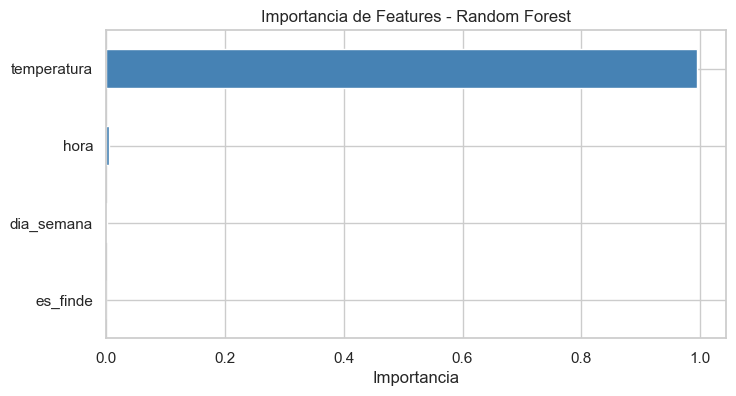

La temperatura es lejos la feature mas importante (por la relacion cuadratica con demanda).


In [6]:
# Importancia de features: que columnas usa mas el modelo?
importancias = pd.Series(rf.feature_importances_, index=features).sort_values(ascending=True)

plt.figure(figsize=(8, 4))
importancias.plot(kind='barh', color='steelblue')
plt.title('Importancia de Features - Random Forest')
plt.xlabel('Importancia')
plt.show()
print("La temperatura es lejos la feature mas importante (por la relacion cuadratica con demanda).")

> **¿Qué nos dice este gráfico?** Muestra qué columnas (features) usa más el modelo para hacer sus predicciones. La temperatura domina porque la relación con la demanda es cuadrática (la vimos en el Módulo 1). Es información muy valiosa para el negocio: si tuviéramos que elegir un solo sensor para monitorear, sería el de temperatura.

### 1.3 XGBoost (eXtreme Gradient Boosting)

![Boosting](https://media.geeksforgeeks.org/wp-content/uploads/20200721214745/gradientboosting.PNG)

A diferencia de Random Forest (árboles en paralelo), XGBoost entrena árboles **en secuencia**:
1. El primer árbol hace una predicción.
2. El segundo árbol se enfoca en los **errores** del primero.
3. El tercero corrige los errores del segundo.
4. Y así sucesivamente...

Es uno de los algoritmos **más usados en la industria** para datos tabulares (tablas). Si sus datos están en formato tabular, XGBoost probablemente sea su mejor opción.

In [7]:
# Entrenar XGBoost
modelo_xgb = xgb.XGBRegressor(
    n_estimators=100,
    max_depth=5,
    learning_rate=0.1,
    random_state=42
)
modelo_xgb.fit(X_train, y_train)
pred_xgb = modelo_xgb.predict(X_test)

mae_xgb = mean_absolute_error(y_test, pred_xgb)
print(f"XGBoost: MAE = {mae_xgb:.2f} MW")

XGBoost: MAE = 4.68 MW


> **Lectura de resultado:** XGBoost logra un MAE similar o mejor que Random Forest. En la práctica, XGBoost suele ser la opción preferida en la industria por su velocidad y precisión. **Si solo pudieran usar un modelo para datos tabulares, elijan XGBoost.**

### 1.4 Comparación de todos los modelos

Ahora viene el momento de la verdad: ¿realmente los ensembles mejoran respecto a los modelos simples del Módulo 1?

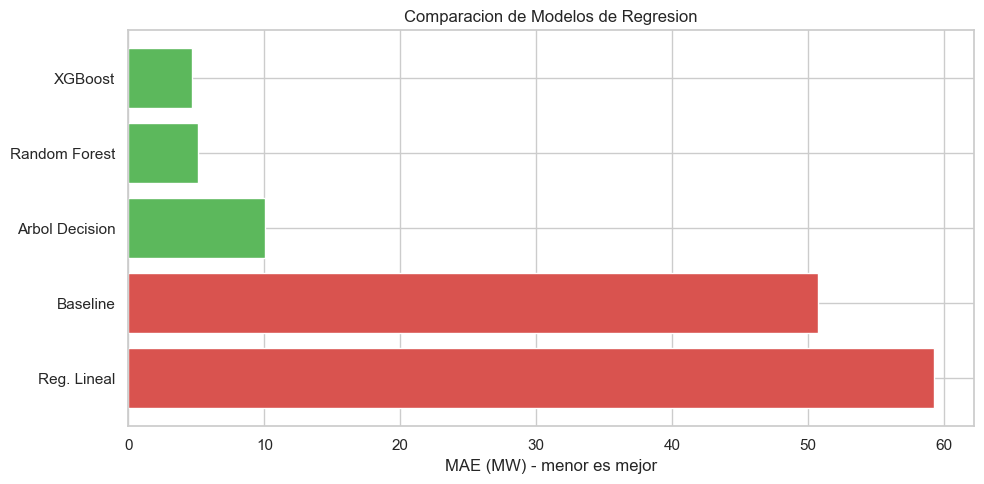

  XGBoost              MAE: 4.68 MW
  Random Forest        MAE: 5.10 MW
  Arbol Decision       MAE: 10.02 MW
  Baseline             MAE: 50.70 MW
  Reg. Lineal          MAE: 59.24 MW


In [8]:
# Tabla comparativa
resultados = pd.DataFrame({
    'Modelo': ['Baseline', 'Reg. Lineal', 'Arbol Decision', 'Random Forest', 'XGBoost'],
    'MAE (MW)': [mae_baseline, mae_lr, mae_dt, mae_rf, mae_xgb]
}).sort_values('MAE (MW)', ascending=False)

plt.figure(figsize=(10, 5))
colores = ['#d9534f' if m > mae_dt else '#5cb85c' for m in resultados['MAE (MW)']]
plt.barh(resultados['Modelo'], resultados['MAE (MW)'], color=colores)
plt.xlabel('MAE (MW) - menor es mejor')
plt.title('Comparacion de Modelos de Regresion')
plt.tight_layout()
plt.show()

for _, row in resultados.sort_values('MAE (MW)').iterrows():
    print(f"  {row['Modelo']:20s} MAE: {row['MAE (MW)']:.2f} MW")

> **¿Qué nos dice este gráfico?** Las barras rojas son los modelos que rinden peor que el Árbol de Decisión, y las verdes los que lo superan. Los modelos de ensamble (Random Forest y XGBoost) están claramente en el grupo verde. La mejora no es magia — viene de combinar muchos modelos simples de forma inteligente.

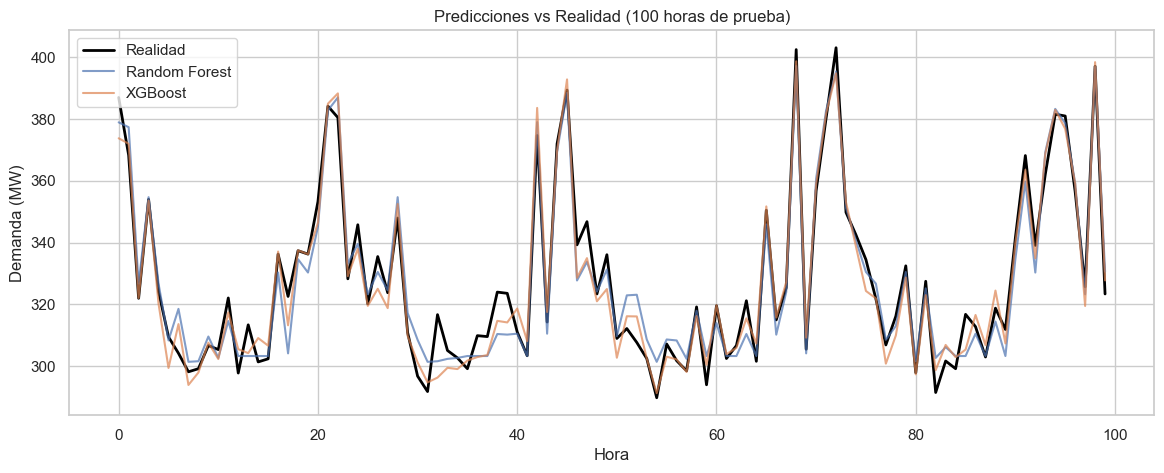

In [9]:
# Predicciones vs realidad (primeras 100 horas del test)
plt.figure(figsize=(14, 5))
rango = 100
plt.plot(y_test.values[:rango], label='Realidad', color='black', linewidth=2)
plt.plot(pred_rf[:rango], label='Random Forest', alpha=0.7)
plt.plot(pred_xgb[:rango], label='XGBoost', alpha=0.7)
plt.title('Predicciones vs Realidad (100 horas de prueba)')
plt.ylabel('Demanda (MW)')
plt.xlabel('Hora')
plt.legend()
plt.show()

> **¿Qué nos dice este gráfico?** La línea negra es la demanda real. Las líneas de colores son las predicciones de Random Forest y XGBoost. Fíjense cómo ambos modelos siguen bastante bien el patrón real, capturando los picos y valles de la demanda horaria. Donde más se equivocan es en los picos extremos — eso es normal y difícil de predecir.

### 1.5 Stacking (conceptual)

**Idea:** Usar las predicciones de varios modelos como features de un "meta-modelo".

```
Datos --> Modelo A --> prediccion_A ─┐
Datos --> Modelo B --> prediccion_B ──┼── Meta-modelo --> Prediccion final
Datos --> Modelo C --> prediccion_C ─┘
```

Es como tener un jefe que toma la decision final basandose en lo que dicen sus analistas.

No lo implementamos hoy, pero sepan que existe. En la practica, **XGBoost solo suele ser suficiente** para la mayoria de los casos.

---

### Para seguir explorando: Ensembles

Ejercicios para explorar en casa. No hace falta entregar nada — son para que experimenten y vean cómo reaccionan los modelos.

**1. Jugar con los hiperparámetros de Random Forest:**
Cambien `n_estimators` (cantidad de árboles) y `max_depth` (profundidad máxima) y vean cómo cambia el MAE.

```python
# Probar con distintas configuraciones
for n_arboles in [10, 50, 100, 500]:
    for profundidad in [3, 5, 8, 15]:
        rf_test = RandomForestRegressor(n_estimators=n_arboles, max_depth=profundidad, random_state=42)
        rf_test.fit(X_train, y_train)
        mae = mean_absolute_error(y_test, rf_test.predict(X_test))
        print(f"Árboles={n_arboles:3d}, Profundidad={profundidad:2d} → MAE={mae:.2f}")
```

**2. Agregar features del Módulo 1:**
¿Se acuerdan de `temperatura^2`? Prueben agregar esa feature y vean si mejora.

```python
# Agregar temperatura al cuadrado
df['temp_cuadrado'] = df['temperatura'] ** 2
features_v2 = ['temperatura', 'temp_cuadrado', 'hora', 'dia_semana', 'es_finde']
# Re-entrenar XGBoost con las nuevas features y comparar MAE
```

**3. Pregunta para pensar:** Si tuvieran que predecir la demanda de su distribuidora, ¿qué otras columnas agregarían al modelo? (feriados, eventos especiales, estado del clima...)

---

## Bloque 2: Deep Learning para Series Temporales

### 2.1 ¿Qué es una red neuronal?

![Red Neuronal](https://miro.medium.com/v2/0*62iuBHMJQncV3IkQ.gif)

Una red neuronal es una función matemática con **muchos parámetros ajustables** organizados en capas:

```
Entrada (features)  -->  Capa 1  -->  Capa 2  -->  ...  -->  Salida (predicción)
  [temp, hora, ...]     [64 neuronas]  [32 neuronas]          [1 valor: demanda]
```

Cada "capa" transforma los datos de la capa anterior, y al final obtenemos el resultado. Los parámetros de cada transformación se **ajustan automáticamente** durante el entrenamiento.

**¿Cuándo usar Deep Learning?**

| Sí usar DL | No usar DL |
|------------|------------|
| Muchos datos (miles/millones de registros) | Pocos datos (menos de ~5000 registros) |
| Patrones complejos en secuencias, imágenes o texto | Datos tabulares simples (XGBoost suele ganar) |
| Cuando modelos clásicos ya no mejoran | Se necesita explicabilidad ("¿por qué predijo esto?") |
| | Recursos computacionales limitados |

### 2.2 Preparar datos para series temporales: ventanas

![SlidingWindow](https://d33wubrfki0l68.cloudfront.net/f9e6d3495ba5437512a3ff12ac0bdef7fa1745ae/7ef53/images/backtesting_refit_fixed_train_size.gif)

Para predecir la demanda de la **próxima hora**, le damos al modelo las **últimas 24 horas** como contexto.

```
Ventana de entrada (24h)          Target
─────────────────────────         ──────
[h1, h2, h3, ..., h24]    -->    h25
[h2, h3, h4, ..., h25]    -->    h26
[h3, h4, h5, ..., h26]    -->    h27
```

Cada fila del dataset se convierte en "las últimas 24 horas → la hora siguiente". El modelo aprende patrones en esa secuencia.

In [10]:
# Preparar datos con ventanas de 24 horas
VENTANA = 24
datos_demanda = df['demanda_MW'].values

# Normalizar entre 0 y 1 (las redes neuronales funcionan mejor asi)
scaler = MinMaxScaler()
datos_norm = scaler.fit_transform(datos_demanda.reshape(-1, 1)).flatten()

# Crear ventanas
def crear_ventanas(datos, ventana=24):
    X, y = [], []
    for i in range(ventana, len(datos)):
        X.append(datos[i-ventana:i])
        y.append(datos[i])
    return np.array(X), np.array(y)

X_series, y_series = crear_ventanas(datos_norm, VENTANA)
print(f"Ventanas creadas: {X_series.shape[0]}")
print(f"Cada ventana tiene {X_series.shape[1]} horas de historia")

Ventanas creadas: 8760
Cada ventana tiene 24 horas de historia


> **¿Qué hicimos?** Transformamos nuestra serie temporal en miles de "ventanas" de 24 horas. Cada ventana es un ejemplo de entrenamiento. También normalizamos los datos entre 0 y 1 porque las redes neuronales funcionan mejor con valores pequeños.

In [11]:
# Split (mismo punto de corte cronologico)
corte_series = corte - VENTANA

X_train_s = X_series[:corte_series]
X_test_s = X_series[corte_series:]
y_train_s = y_series[:corte_series]
y_test_s = y_series[corte_series:]

# Reshape para Keras: (muestras, pasos_temporales, features)
X_train_s = X_train_s.reshape(-1, VENTANA, 1)
X_test_s = X_test_s.reshape(-1, VENTANA, 1)

print(f"Train: {X_train_s.shape}, Test: {X_test_s.shape}")

Train: (7003, 24, 1), Test: (1757, 24, 1)


### 2.3 Red Neuronal Simple (MLP - Perceptrón Multicapa)

Empecemos con lo más básico: una red que toma las 24 horas, las "aplana" en un vector, y las pasa por capas densas (cada neurona conectada con todas las de la capa siguiente).

**Limitación:** Esta red NO entiende que los datos son secuenciales. Para ella, la hora 1 y la hora 24 son simplemente "números en posiciones diferentes" — perdemos el orden temporal.

In [12]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, LSTM, Flatten

# Red neuronal simple: aplanar las 24 horas y pasar por capas densas
modelo_dense = Sequential([
    Flatten(input_shape=(VENTANA, 1)),   # 24 valores -> vector plano
    Dense(64, activation='relu'),         # Capa oculta 1
    Dense(32, activation='relu'),         # Capa oculta 2
    Dense(1)                              # Salida: 1 valor (demanda)
])

modelo_dense.compile(optimizer='adam', loss='mse')
modelo_dense.summary()

/Users/farduh/xcapit/Capacitaci-nIA/.venv/lib/python3.13/site-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 24)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         1,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,713 (14.50 KB)

 Trainable params: 3,713 (14.50 KB)

 Non-trainable params: 0 (0.00 B)

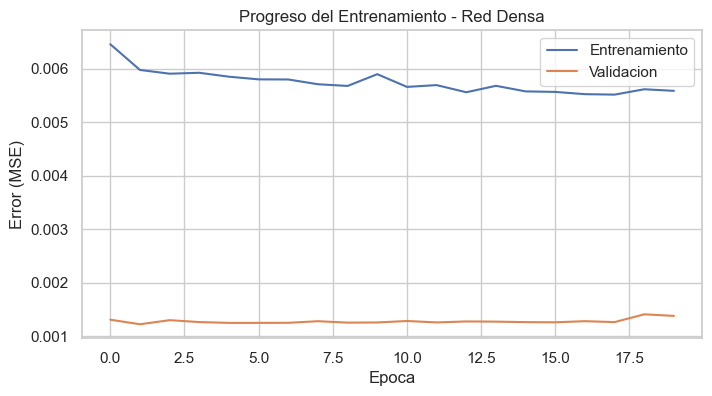

In [13]:
# Entrenar (epochs = cuantas veces el modelo ve todos los datos)
historia_dense = modelo_dense.fit(
    X_train_s, y_train_s,
    epochs=20,
    batch_size=64,
    validation_split=0.1,
    verbose=0,  # Silenciar output
)

# Graficar progreso del entrenamiento
plt.figure(figsize=(8, 4))
plt.plot(historia_dense.history['loss'], label='Entrenamiento')
plt.plot(historia_dense.history['val_loss'], label='Validacion')
plt.title('Progreso del Entrenamiento - Red Densa')
plt.xlabel('Epoca')
plt.ylabel('Error (MSE)')
plt.legend()
plt.show()

> **¿Qué nos dice este gráfico?** Las dos curvas muestran cómo baja el error a medida que el modelo entrena. La curva azul es el error en los datos de entrenamiento, la naranja en datos de validación (datos que el modelo no vio). Lo ideal es que **ambas bajen juntas**. Si la de entrenamiento baja pero la de validación sube, el modelo está memorizando en vez de aprender (overfitting).

In [14]:
# Evaluar: des-normalizar predicciones para obtener MW reales
pred_dense_norm = modelo_dense.predict(X_test_s, verbose=0).flatten()
pred_dense_mw = scaler.inverse_transform(pred_dense_norm.reshape(-1, 1)).flatten()
y_test_mw = scaler.inverse_transform(y_test_s.reshape(-1, 1)).flatten()

mae_dense = mean_absolute_error(y_test_mw, pred_dense_mw)
print(f"MAE Red Densa: {mae_dense:.2f} MW")

MAE Red Densa: 27.48 MW


> **Lectura de resultado:** La red densa (MLP) logra un cierto MAE. Comparemos después con XGBoost y LSTM para ver si la complejidad adicional de Deep Learning vale la pena en este caso. Recuerden: más complejidad no siempre significa mejor resultado.

### 2.4 LSTM (Long Short-Term Memory)

![RNN](https://miro.medium.com/v2/1*go8PHsPNbbV6qRiwpUQ5BQ.png)

![LTSM](https://miro.medium.com/v2/1*zFrSLqF97oZO_o8yJmLIVQ.png)

La red densa trata las 24 horas como valores independientes. Pero en una serie temporal, **el orden importa**: la hora 23 está conectada con la hora 22, que está conectada con la 21...

**LSTM** es un tipo de red neuronal con **memoria**: recuerda lo que vio en pasos anteriores de la secuencia.

**¿Por qué "Long Short-Term Memory"?** Porque resuelve un problema específico: las redes recurrentes básicas "olvidan" rápido. LSTM tiene mecanismos internos (compuertas) que deciden **qué recordar y qué olvidar**.

In [15]:
# Modelo LSTM
modelo_lstm = Sequential([
    LSTM(50, input_shape=(VENTANA, 1)),  # 50 unidades de memoria
    Dense(1)
])

modelo_lstm.compile(optimizer='adam', loss='mse')

historia_lstm = modelo_lstm.fit(
    X_train_s, y_train_s,
    epochs=20,
    batch_size=64,
    validation_split=0.1,
    verbose=0
)
print("LSTM entrenado.")

/Users/farduh/xcapit/Capacitaci-nIA/.venv/lib/python3.13/site-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


LSTM entrenado.


In [16]:
# Evaluar LSTM
pred_lstm_norm = modelo_lstm.predict(X_test_s, verbose=0).flatten()
pred_lstm_mw = scaler.inverse_transform(pred_lstm_norm.reshape(-1, 1)).flatten()

mae_lstm = mean_absolute_error(y_test_mw, pred_lstm_mw)
print(f"MAE LSTM: {mae_lstm:.2f} MW")

MAE LSTM: 27.48 MW


> **Lectura de resultado:** LSTM aprovecha el orden temporal de la secuencia, lo que debería darle una ventaja sobre la red densa. Veamos cómo se compara visualmente con la demanda real.

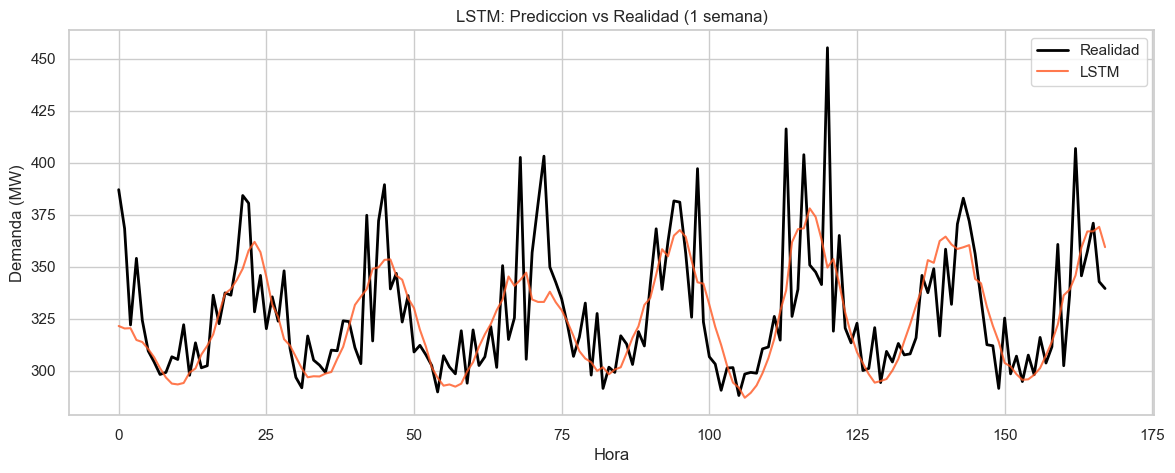

In [17]:
# Visualizar predicciones LSTM vs realidad (una semana)
plt.figure(figsize=(14, 5))
rango = 168  # 1 semana = 168 horas
plt.plot(y_test_mw[:rango], label='Realidad', color='black', linewidth=2)
plt.plot(pred_lstm_mw[:rango], label='LSTM', alpha=0.8, color='#FF5722')
plt.title('LSTM: Prediccion vs Realidad (1 semana)')
plt.ylabel('Demanda (MW)')
plt.xlabel('Hora')
plt.legend()
plt.show()

> **¿Qué nos dice este gráfico?** La línea negra es la demanda real durante una semana (168 horas). La línea naranja es la predicción del LSTM. Pueden ver cómo el modelo captura los ciclos diarios (picos durante el día, valles de madrugada). Las diferencias entre la línea real y la predicción son los errores del modelo.

### 2.5 Comparación: ML Clásico vs Deep Learning

Llegó el momento de comparar **todos** los modelos que vimos hasta ahora, desde el baseline más simple hasta LSTM.

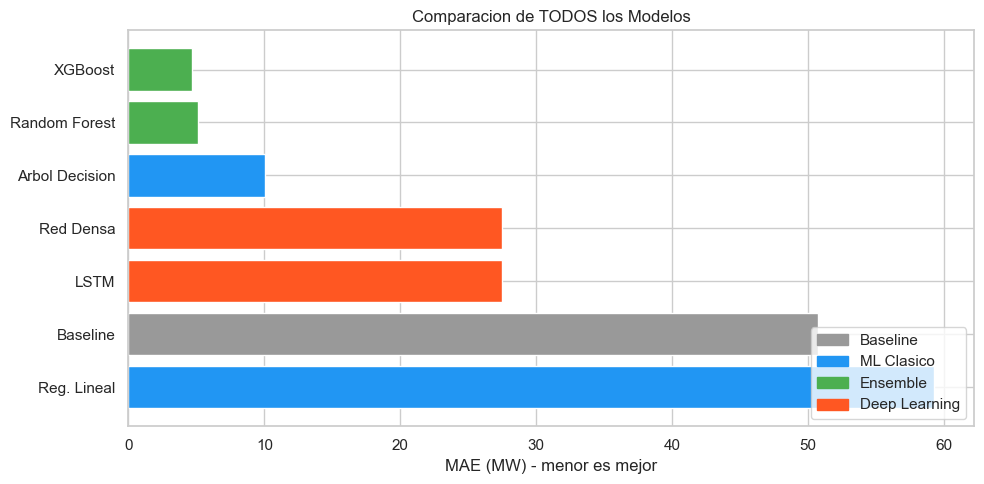


Resumen:
  XGBoost              MAE: 4.68 MW (Ensemble)
  Random Forest        MAE: 5.10 MW (Ensemble)
  Arbol Decision       MAE: 10.02 MW (ML Clasico)
  Red Densa            MAE: 27.48 MW (Deep Learning)
  LSTM                 MAE: 27.48 MW (Deep Learning)
  Baseline             MAE: 50.70 MW (Baseline)
  Reg. Lineal          MAE: 59.24 MW (ML Clasico)


In [18]:
# Tabla comparativa final
todos = pd.DataFrame({
    'Modelo': ['Baseline', 'Reg. Lineal', 'Arbol Decision', 'Random Forest', 'XGBoost', 'Red Densa', 'LSTM'],
    'MAE (MW)': [mae_baseline, mae_lr, mae_dt, mae_rf, mae_xgb, mae_dense, mae_lstm],
    'Tipo': ['Baseline', 'ML Clasico', 'ML Clasico', 'Ensemble', 'Ensemble', 'Deep Learning', 'Deep Learning']
}).sort_values('MAE (MW)', ascending=False)

plt.figure(figsize=(10, 5))
colores_tipo = {'Baseline': '#999', 'ML Clasico': '#2196F3', 'Ensemble': '#4CAF50', 'Deep Learning': '#FF5722'}
plt.barh(todos['Modelo'], todos['MAE (MW)'], color=[colores_tipo[t] for t in todos['Tipo']])
plt.xlabel('MAE (MW) - menor es mejor')
plt.title('Comparacion de TODOS los Modelos')

from matplotlib.patches import Patch
plt.legend(handles=[Patch(color=c, label=l) for l, c in colores_tipo.items()], loc='lower right')
plt.tight_layout()
plt.show()

print("\nResumen:")
for _, row in todos.sort_values('MAE (MW)').iterrows():
    print(f"  {row['Modelo']:20s} MAE: {row['MAE (MW)']:.2f} MW ({row['Tipo']})")

> **¿Qué nos dice este gráfico?** Es el "ranking final" de todos los modelos. Cada color representa un tipo de modelo (gris=baseline, azul=ML clásico, verde=ensembles, naranja=Deep Learning). **Conclusión clave:** los ensembles (XGBoost, Random Forest) ganan claramente a Deep Learning en este caso. ¿Por qué? Porque los ensembles reciben **múltiples features** (temperatura, hora, día de semana, etc.), mientras que las redes neuronales solo reciben la **serie temporal univariada** (las últimas 24 horas de demanda, sin features adicionales). Es una comparación desigual, pero ilustra un punto importante: **más complejidad no siempre significa mejor resultado**, y la elección de features importa tanto o más que la elección del modelo.

### Conclusiones: DL vs ML Clásico

| Aspecto | ML Clásico (XGBoost) | Deep Learning (LSTM) |
|---------|---------------------|-----------------------|
| Datos necesarios | Funciona bien con pocos | Necesita muchos datos |
| Velocidad de entrenamiento | Rápido (segundos) | Lento (minutos/horas) |
| Explicabilidad | Alta (feature importances) | Baja (caja negra) |
| Datos tabulares | Generalmente gana | No necesariamente mejor |
| Secuencias largas | Limitado | Excelente |
| Cómputo necesario | CPU suficiente | GPU recomendado |
| Mantenimiento | Simple | Más complejo (hiperparámetros, arquitectura) |

**Regla práctica:** Para datos tabulares, siempre probar XGBoost primero. Solo ir a DL si hay secuencias largas, datos masivos, o si XGBoost ya no mejora.

### 2.6 Transformers para Series Temporales (conceptual)

La misma arquitectura detrás de ChatGPT se puede adaptar para series temporales.

**¿Cómo funciona la "atención"?** En vez de procesar la secuencia paso a paso (como LSTM), los Transformers pueden mirar **toda la secuencia a la vez** y decidir qué partes son más relevantes para la predicción.

**Ventajas sobre LSTM:**
- Capturan dependencias de largo plazo mejor
- Se entrenan más rápido en paralelo
- Pueden manejar múltiples series a la vez

**Modelos existentes que pueden usar sin implementar desde cero:**
- **Temporal Fusion Transformer** (Google) — para pronósticos con variables exógenas
- **TimeGPT** (Nixtla) — API que funciona como "ChatGPT para series de tiempo"
- **Chronos** (Amazon) — modelo pre-entrenado de series temporales

No los implementamos hoy, pero sepan que existen y son el **estado del arte** para pronóstico multi-horizonte.

---

### Para seguir explorando: Deep Learning

**1. Cambiar el tamaño de la ventana:**
¿Qué pasa si en vez de mirar las últimas 24 horas, miramos 12 o 48?

```python
# Probar con ventana de 48 horas
VENTANA_48 = 48
X_48, y_48 = crear_ventanas(datos_norm, VENTANA_48)
# Dividir, entrenar un LSTM y comparar MAE contra VENTANA=24
```

*Pista: una ventana más grande da más contexto, pero también más datos para procesar y puede ser más lento.*

**2. Agregar más capas al LSTM:**

```python
from tensorflow.keras.layers import Dropout

modelo_lstm_v2 = Sequential([
    LSTM(64, return_sequences=True, input_shape=(VENTANA, 1)),  # Primera capa LSTM
    Dropout(0.2),                                                # Evitar overfitting
    LSTM(32),                                                    # Segunda capa LSTM
    Dense(1)
])
modelo_lstm_v2.compile(optimizer='adam', loss='mse')
# Entrenar y comparar contra el LSTM original
```

**3. Pregunta para pensar:** ¿En qué problemas de su día a día tienen datos secuenciales que podrían modelarse con estas técnicas?

---

## Bloque 3: Aprendizaje por Refuerzo

![Aprendizaje por Refuerzo - Grid World](https://towardsdatascience.com/wp-content/uploads/2022/09/1af0diz6xweH1deJj7Pn0oQ.gif)

*El agente (personaje) debe aprender a llegar al tesoro evitando obstáculos, recibiendo recompensas por acercarse y penalidades por caer en el hielo.*

### 3.1 ¿Qué es?

Un **agente** aprende a tomar **decisiones** interactuando con un **entorno**, recibiendo **recompensas** o **penalidades** según sus acciones.

```
                    Observa el Estado
              ┌────────────────────────┐
              │                        │
              v                        │
         ┌─────────┐            ┌──────────┐
         │  AGENTE  │──Acción──>│ ENTORNO  │
         └─────────┘            └──────────┘
              ^                        │
              │   Recompensa           │
              └────────────────────────┘
```

**Diferencia clave con lo que vimos antes:**

| | ML Supervisado (Módulos 1-3) | Aprendizaje por Refuerzo |
|--|-----|------|
| **Datos** | Tenemos las respuestas correctas de antemano | El agente descubre qué es "correcto" por prueba y error |
| **Feedback** | Se compara contra valores conocidos | Se recibe una recompensa numérica que el agente maximiza |

### 3.2 Formulación para Energía

**Caso: Gestión óptima de almacenamiento de energía (batería)**

Imaginemos que tenemos una batería conectada a la red y queremos aprender **cuándo cargar y cuándo descargar** para minimizar costos.

| Concepto RL | Aplicación en Energía |
|-------------|----------------------|
| **Estado** | Nivel de batería, demanda actual, precio de energía, hora |
| **Acciones** | Cargar batería, Descargar batería, No hacer nada |
| **Recompensa** | Minimizar costo de energía + mantener confiabilidad |
| **Episodio** | Un día completo de operación |

El agente aprende: *"Si la demanda es baja y el precio es barato, cargo la batería. Si la demanda es alta y el precio es caro, descargo."*

### 3.3 Casos de uso en Distribución de Energía

1. **Gestión de microrredes:** Decidir cuándo usar energía solar, batería o red para minimizar costos.

2. **Optimización de almacenamiento:** Cargar baterías cuando hay excedente solar, descargar en horas pico.

3. **Control de voltaje:** Ajustar taps de transformadores (mecanismo que sube o baja la tensión de salida en pasos discretos) y bancos de capacitores (conjuntos de capacitores que se conectan/desconectan de la red para corregir tensión) para mantener el voltaje dentro del rango permitido.

4. **Despacho de generadores:** Decidir qué generadores encender/apagar considerando costos y rampas.

5. **Gestión de demanda:** Ofrecer incentivos a clientes para que reduzcan consumo en momentos críticos.

**Estos problemas comparten algo:** hay que tomar **decisiones secuenciales** donde cada decisión afecta el futuro. Eso es exactamente lo que RL resuelve bien.

### 3.4 Demo simplificada: Q-Learning básico

Vamos a ver esto en acción con un ejemplo simplificado. Nuestro agente tiene que aprender cuándo cargar y descargar una batería durante las 24 horas del día para **maximizar su ganancia económica**.

La recompensa es simplemente el resultado financiero: si descarga (vende energía), gana al precio de esa hora. Si carga (compra energía), paga al precio de esa hora. El agente **no sabe cuáles son las horas pico ni las horas valle** — tiene que descubrirlo solo a partir de los precios.

**¿Qué es la tabla Q?** Es una tabla donde las filas son los estados (combinación de hora y nivel de batería) y las columnas son las acciones posibles. Cada celda contiene un "puntaje" que indica qué tan buena es esa acción en ese estado. El agente la va llenando con la experiencia.

```
                    | No hacer nada | Cargar | Descargar |
Hora 0, Bat. baja   |     0.0       |  0.3   |   -0.5    |
Hora 0, Bat. alta   |     0.0       |  -0.1  |    0.2    |
...                  |     ...       |  ...   |    ...    |
Hora 18, Bat. alta   |    -0.1       | -0.3   |    0.9    |
```

In [19]:
# Simulacion de gestion de bateria con precios de energia
# Estado: (hora del dia, nivel de bateria)
# Acciones: 0=no hacer nada, 1=cargar, 2=descargar
# Recompensa: ganancia/perdida economica segun precio de la hora

np.random.seed(42)

# Precios de energia por hora ($/MWh) - el agente NO conoce esta curva,
# solo experimenta el resultado economico de sus acciones
precios = np.array([
    20, 18, 15, 14, 13, 14,   # 0-5h:  madrugada (baratos)
    18, 25, 35, 40, 38, 35,   # 6-11h: mañana (suben)
    32, 30, 32, 35, 42, 55,   # 12-17h: tarde (suben más)
    65, 70, 68, 55, 40, 28    # 18-23h: pico y baja
])

# Niveles de bateria discretos: 0=vacia, 1=media, 2=llena
n_horas = 24
n_niveles = 3
n_acciones = 3  # 0=nada, 1=cargar, 2=descargar
Q = np.zeros((n_horas, n_niveles, n_acciones))

def paso(hora, nivel_bateria, accion):
    """Ejecutar una accion y devolver (recompensa, nuevo_nivel_bateria)"""
    precio = precios[hora]
    nuevo_nivel = nivel_bateria

    if accion == 1:  # Cargar
        if nivel_bateria < 2:  # Solo si no esta llena
            nuevo_nivel = nivel_bateria + 1
            recompensa = -precio  # Pagamos el precio de esa hora
        else:
            recompensa = -5  # Penalidad: intentar cargar bateria llena
    elif accion == 2:  # Descargar
        if nivel_bateria > 0:  # Solo si no esta vacia
            nuevo_nivel = nivel_bateria - 1
            recompensa = precio  # Ganamos el precio de esa hora
        else:
            recompensa = -5  # Penalidad: intentar descargar bateria vacia
    else:  # No hacer nada
        recompensa = 0

    return recompensa, nuevo_nivel

# Entrenar: 2000 episodios (dias simulados)
alpha = 0.1    # Tasa de aprendizaje
gamma = 0.9    # Factor de descuento (importancia del futuro)
epsilon = 0.15 # Exploracion
recompensa_por_episodio = []

for episodio in range(2000):
    nivel = 1  # Bateria empieza a media carga
    ganancia_dia = 0

    for hora in range(24):
        # Elegir accion (epsilon-greedy)
        if np.random.random() < epsilon:
            accion = np.random.randint(n_acciones)  # Explorar
        else:
            accion = np.argmax(Q[hora, nivel])       # Explotar

        r, nuevo_nivel = paso(hora, nivel, accion)
        ganancia_dia += r

        # Actualizar Q con la ecuacion de Bellman
        hora_sig = (hora + 1) % 24
        mejor_futuro = np.max(Q[hora_sig, nuevo_nivel])
        Q[hora, nivel, accion] += alpha * (r + gamma * mejor_futuro - Q[hora, nivel, accion])

        nivel = nuevo_nivel

    recompensa_por_episodio.append(ganancia_dia)

print("Entrenamiento completado!")
print(f"Ganancia promedio ultimos 100 episodios: ${np.mean(recompensa_por_episodio[-100:]):.1f}")
print(f"Ganancia promedio primeros 100 episodios: ${np.mean(recompensa_por_episodio[:100]):.1f}")

Entrenamiento completado!
Ganancia promedio ultimos 100 episodios: $66.3
Ganancia promedio primeros 100 episodios: $10.6


> **¿Qué pasó acá?** Simulamos 2000 días de operación. El agente solo sabe el resultado económico de cada acción (cuánto ganó o perdió), pero **no sabe cuáles son las horas caras ni las baratas**. Con el tiempo fue descubriendo los patrones de precio por prueba y error. Fíjense cómo la ganancia promedio mejora entre los primeros y últimos episodios — el agente fue aprendiendo.

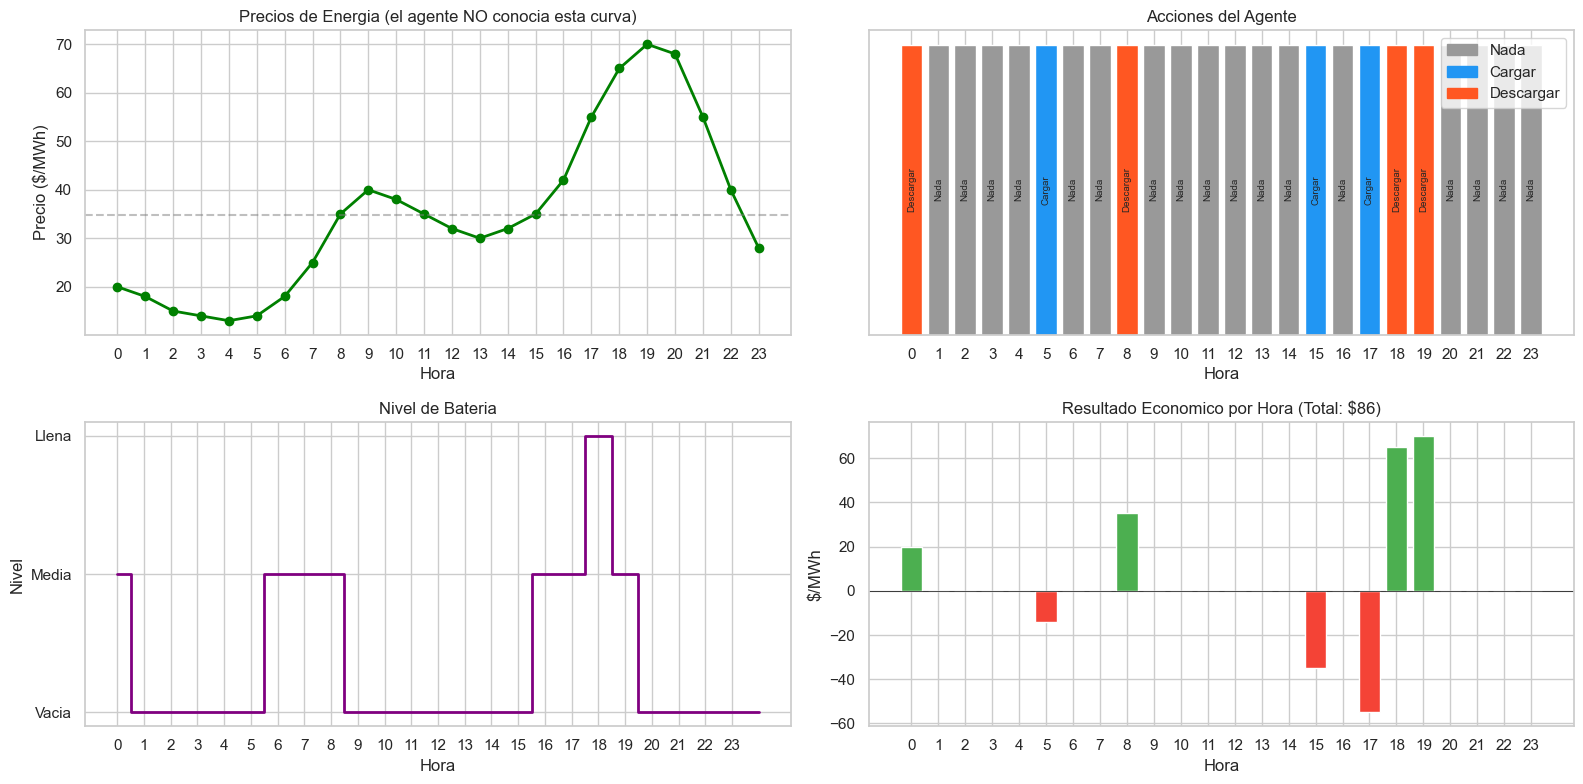

In [20]:
# Simular un dia completo con la politica aprendida
acciones_nombres = ['Nada', 'Cargar', 'Descargar']
nivel = 1  # Bateria empieza a media carga
trayectoria_nivel = [nivel]
trayectoria_accion = []
ganancia_total = 0
ganancias = []

for h in range(24):
    accion_idx = np.argmax(Q[h, nivel])
    r, nuevo_nivel = paso(h, nivel, accion_idx)
    ganancia_total += r
    ganancias.append(r)
    trayectoria_accion.append(acciones_nombres[accion_idx])
    nivel = nuevo_nivel
    trayectoria_nivel.append(nivel)

# Visualizar
fig, axes = plt.subplots(2, 2, figsize=(16, 8))

# 1. Curva de precios
axes[0,0].plot(range(24), precios, 'o-', color='green', linewidth=2)
axes[0,0].set_xticks(range(24))
axes[0,0].set_xlabel('Hora')
axes[0,0].set_ylabel('Precio ($/MWh)')
axes[0,0].set_title('Precios de Energia (el agente NO conocia esta curva)')
axes[0,0].axhline(y=np.mean(precios), color='gray', linestyle='--', alpha=0.5)

# 2. Acciones del agente
colores_acc = {'Nada': '#999', 'Cargar': '#2196F3', 'Descargar': '#FF5722'}
axes[0,1].bar(range(24), [1]*24, color=[colores_acc[a] for a in trayectoria_accion])
axes[0,1].set_xticks(range(24))
axes[0,1].set_xlabel('Hora')
axes[0,1].set_title('Acciones del Agente')
axes[0,1].set_yticks([])
for i, a in enumerate(trayectoria_accion):
    axes[0,1].text(i, 0.5, a, ha='center', va='center', fontsize=7, rotation=90)
axes[0,1].legend(handles=[Patch(color=c, label=l) for l, c in colores_acc.items()])

# 3. Nivel de bateria a lo largo del dia
axes[1,0].step(range(25), trayectoria_nivel, where='mid', color='purple', linewidth=2)
axes[1,0].set_xticks(range(24))
axes[1,0].set_xlabel('Hora')
axes[1,0].set_ylabel('Nivel')
axes[1,0].set_title('Nivel de Bateria')
axes[1,0].set_yticks([0, 1, 2])
axes[1,0].set_yticklabels(['Vacia', 'Media', 'Llena'])

# 4. Resultado economico por hora
colores_ganancia = ['#4CAF50' if g > 0 else '#F44336' if g < 0 else '#999' for g in ganancias]
axes[1,1].bar(range(24), ganancias, color=colores_ganancia)
axes[1,1].set_xticks(range(24))
axes[1,1].set_xlabel('Hora')
axes[1,1].set_ylabel('$/MWh')
axes[1,1].set_title(f'Resultado Economico por Hora (Total: ${ganancia_total:.0f})')
axes[1,1].axhline(y=0, color='black', linewidth=0.5)

plt.tight_layout()
plt.show()

> **¿Qué nos dicen estos gráficos?** Arriba a la izquierda vemos los precios que el agente **nunca vio directamente**. Arriba a la derecha, las acciones que aprendió a tomar. Abajo a la izquierda, cómo varía el nivel de batería durante el día. Abajo a la derecha, el resultado económico hora a hora (verde = ganancia, rojo = gasto). El agente descubrió una estrategia de arbitraje: **comprar barato y vender caro**, incluyendo un ciclo intermedio durante la mañana. Nadie le programó esas reglas — las aprendió solo experimentando 2000 días.

### Para seguir explorando: Aprendizaje por Refuerzo

**1. Agregar ruido a los precios:**
En la realidad los precios no son iguales todos los días. ¿Qué pasa si agregamos variabilidad?

```python
# Agregar ruido gaussiano a los precios en cada episodio
precio_hora = precios[hora] + np.random.normal(0, 5)  # +/- $5 de ruido
# ¿El agente sigue aprendiendo una buena politica?
```

**2. Cambiar la exploración (epsilon):**

```python
# ¿Qué pasa si el agente explora más (epsilon=0.5) o menos (epsilon=0.01)?
# Probar y graficar la política resultante
# epsilon alto = más exploración, aprende más lento pero puede encontrar mejores estrategias
# epsilon bajo = explota lo que ya sabe, aprende rápido pero puede quedarse en una solución subóptima
```

**3. Más niveles de batería:**

```python
# ¿Qué pasa si la batería tiene 5 niveles en vez de 3?
# n_niveles = 5 → el agente tiene más flexibilidad
# ¿Cambia la estrategia? ¿Aprende a hacer cargas/descargas parciales?
```

**4. Pregunta para pensar:** ¿Hay algún proceso en su trabajo donde se toman decisiones secuenciales que podrían optimizarse con este enfoque?

---
## ¿Cuándo usar qué? Guía rápida de decisión


```
¿Tengo datos etiquetados (target)?
├── SÍ → Supervisado
│   ├── Target es un número? → REGRESIÓN (XGBoost, Random Forest)
│   └── Target es una categoría? → CLASIFICACIÓN (XGBoost, Logística)
├── NO → No Supervisado
│   ├── Quiero agrupar? → CLUSTERING (K-Means)
│   └── Quiero reducir columnas? → PCA
└── ¿Tengo que tomar decisiones secuenciales? → APRENDIZAJE POR REFUERZO

¿Datos tabulares? → XGBoost primero, siempre.
¿Secuencias temporales largas? → LSTM / Transformers.
¿Necesito explicabilidad? → Árbol / Random Forest.
```

**Mensaje clave:** No siempre necesitan el modelo más complejo. En la mayoría de los problemas de datos tabulares (que es lo que manejan las distribuidoras), **XGBoost es el punto de partida ideal**. Solo escalen a Deep Learning cuando realmente lo necesiten.

## Conclusión del Módulo 3

| Lo que vimos | Modelo | Para qué | Cuándo usarlo |
|-------------|--------|----------|---------------|
| Ensembles | Random Forest, XGBoost | Mejor precisión en datos tabulares | Siempre como primera opción |
| Deep Learning | Red Densa, LSTM | Series temporales, secuencias | Cuando hay muchos datos y patrones complejos |
| Transformers | (Conceptual) | Estado del arte en secuencias | Cuando LSTM no alcanza o necesitan multi-horizonte |
| RL | Q-Learning | Decisiones secuenciales | Gestión de baterías, microrredes, despacho |

### Próximo módulo:

**Módulo 4: IA Generativa** — LLMs, embeddings, RAG con documentación técnica, copilotos de código y datos sintéticos.

*¡Van a poder hacerle preguntas en lenguaje natural a sus procedimientos operativos!*